## 12-06-2026 EXPLORATORY DATA ANALYSIS (EDA)
Second statistics class. Last time was the concepts (central tendency, spread, distributions). Today we apply them to a real dataset end to end: load it, clean it, understand it with statistics and plots, then build a simple model to see where it all leads.

This is a basic data science pipeline on the Pima Indians Diabetes dataset. Each patient has 8 medical measurements, and Outcome is 1 if they have diabetes, 0 if not. The goal of EDA is to understand the data before doing anything with it.

Steps today:
1. Load and inspect the data
2. Descriptive statistics
3. Spot and fix invalid zeros (missing values)
4. Impute the missing values
5. Visualize distributions and relationships
6. Scale the features
7. Train/test split and cross validation
8. Build and tune a KNN model
9. Evaluate it (confusion matrix, precision/recall, ROC AUC)

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(7)

### Loading the Dataset

In [2]:
# read_csv loads the file into a DataFrame. head() shows the first 5 rows
diabetes_data = pd.read_csv('diabetes.csv')
diabetes_data.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


### Basic Info
`info()` gives the data types, the non-null count per column, and memory usage. It is the quickest way to check sizes and spot missing values.

In [3]:
# info - dtypes, null counts, memory. All 768 rows are non-null (no obvious NaNs yet)
diabetes_data.info(verbose=True)

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


### Descriptive Statistics
`describe()` summarizes each numeric column: count, mean, std, min, the quartiles (25/50/75 percent), and max. This is exactly the descriptive statistics from class 1, computed on every column at once. The quartiles help spot outliers, and the min values are about to reveal a problem.

In [4]:
# describe - summary stats for the numeric columns
diabetes_data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [5]:
# .T transposes it so each feature is a row, easier to read
diabetes_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


### The Problem Hiding in the Summary
Look at the min values. For these columns a value of 0 is impossible for a living person, so a 0 really means the value was missing and recorded as 0:

- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI

(Pregnancies and Outcome can genuinely be 0, so we leave those alone.)

It is better to replace these zeros with NaN, so we can count them properly and then fill them with sensible values.

In [6]:
# copy the data, then replace 0 with NaN only in the columns where 0 is invalid
diabetes_data_copy = diabetes_data.copy(deep=True)
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
diabetes_data_copy[cols] = diabetes_data_copy[cols].replace(0, np.nan)

# now count the real missing values
diabetes_data_copy.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

### Visualizing Distributions Before Imputation
Plot a histogram of every column to see its shape. The shape tells us how to fill the missing values: a roughly symmetric column can use the mean, a skewed one is better filled with the median (which outliers do not distort, from class 1).

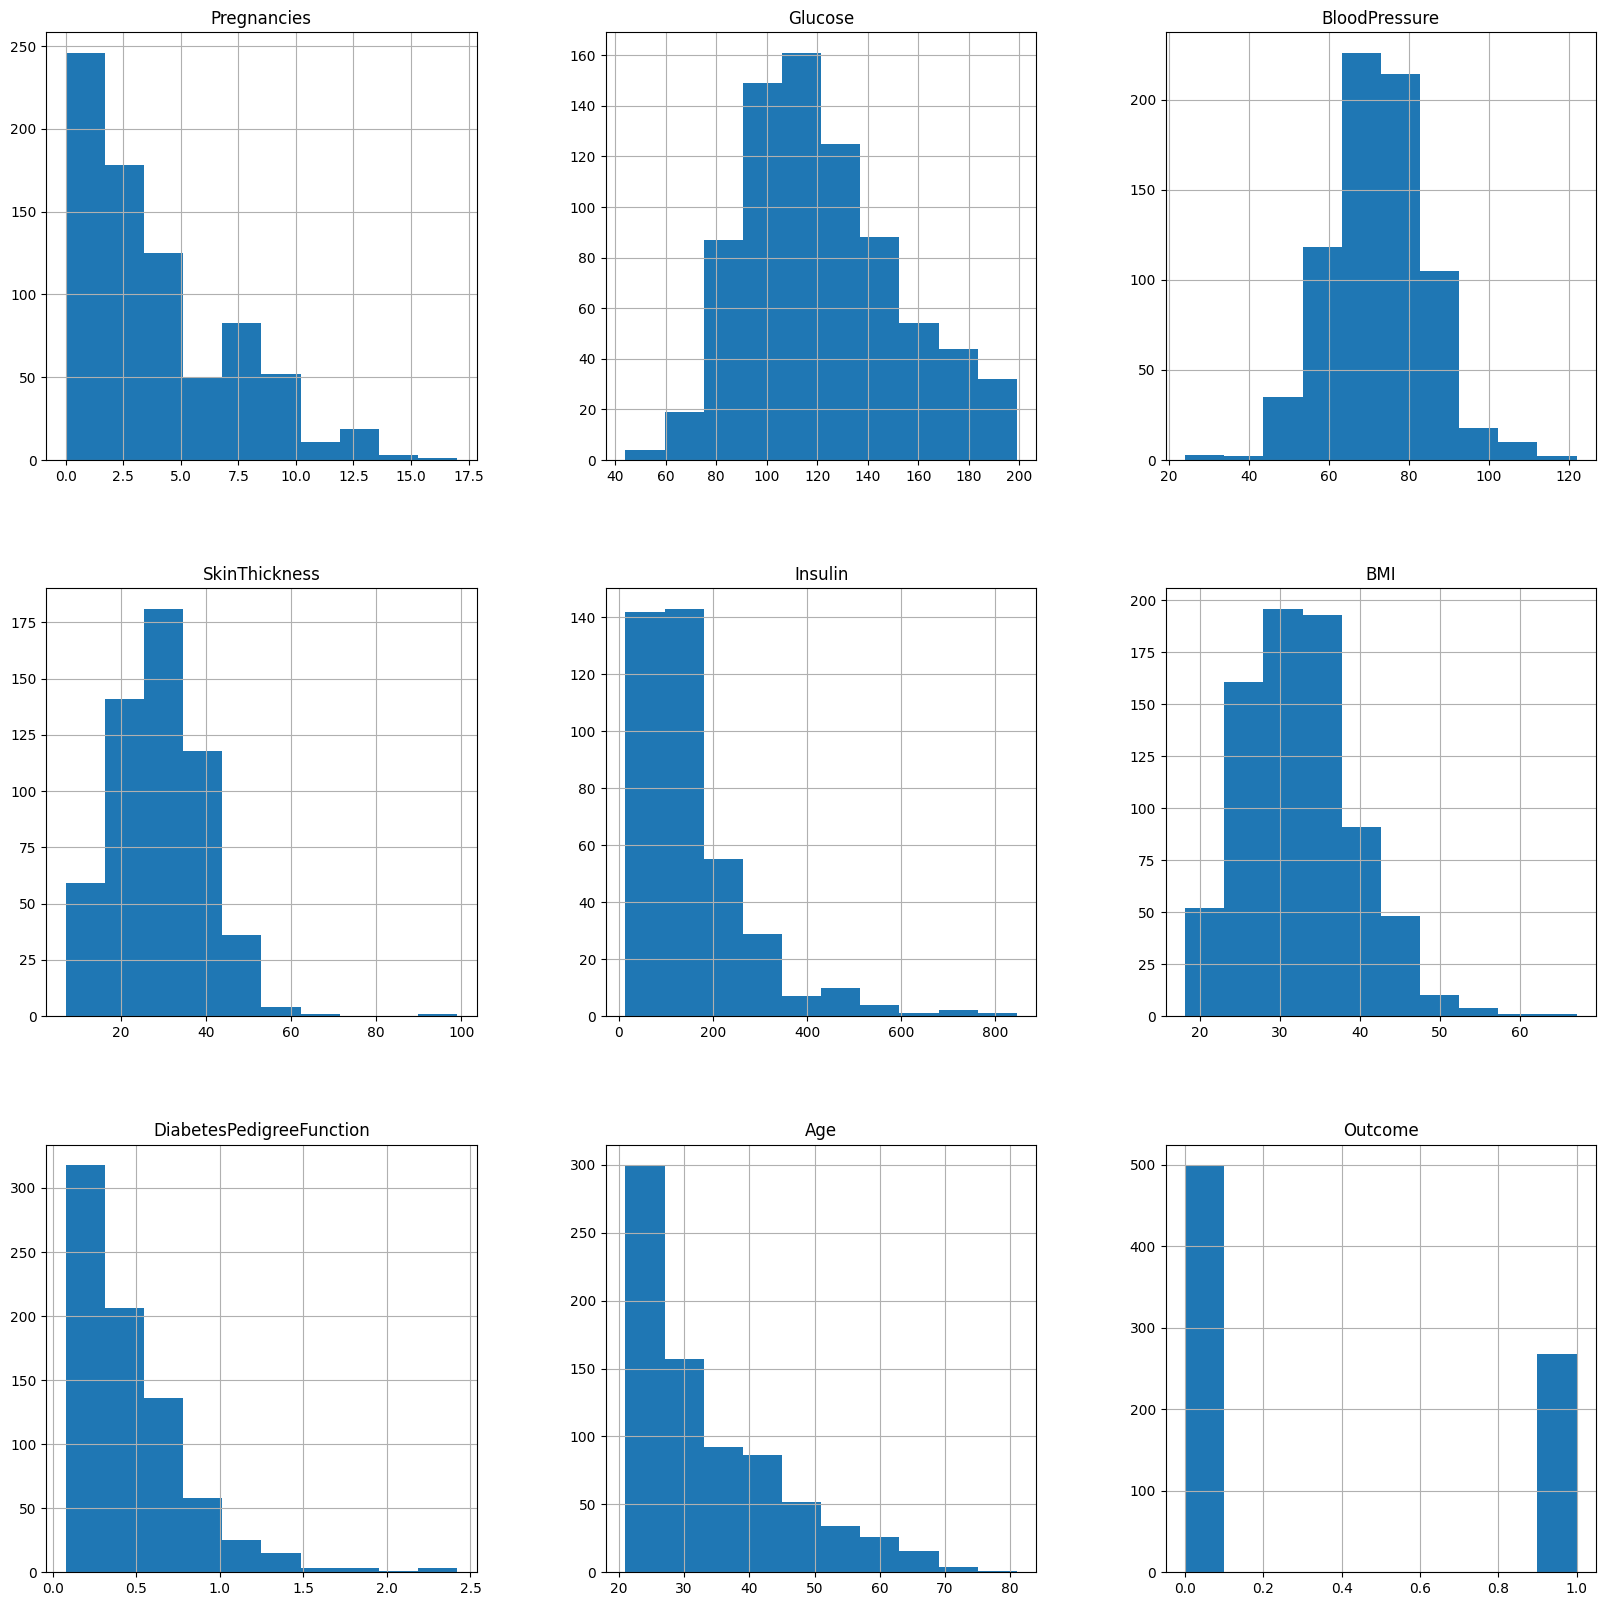

In [7]:
# hist draws one histogram per column
p = diabetes_data_copy.hist(figsize=(20, 20))
plt.show()

### Imputing the Missing Values
Fill each column's NaNs based on its shape:

- Glucose and BloodPressure are fairly symmetric, so fill with the **mean**
- SkinThickness, Insulin and BMI are skewed, so fill with the **median** (robust to outliers)

`fillna(value, inplace=True)` does the replacement in place. We check `isna().sum()` after each so we can watch the missing count drop to zero.

In [8]:
# symmetric columns -> mean
diabetes_data_copy['Glucose'] = diabetes_data_copy['Glucose'].fillna(diabetes_data_copy['Glucose'].mean())
diabetes_data_copy['BloodPressure'] = diabetes_data_copy['BloodPressure'].fillna(diabetes_data_copy['BloodPressure'].mean())

# skewed columns -> median
diabetes_data_copy['SkinThickness'] = diabetes_data_copy['SkinThickness'].fillna(diabetes_data_copy['SkinThickness'].median())
diabetes_data_copy['Insulin'] = diabetes_data_copy['Insulin'].fillna(diabetes_data_copy['Insulin'].median())
diabetes_data_copy['BMI'] = diabetes_data_copy['BMI'].fillna(diabetes_data_copy['BMI'].median())

diabetes_data_copy.isna().sum()   # all zeros now: imputation done

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

### Distributions After Imputation
Re-plot the histograms. The shapes are cleaner now that the fake zeros are gone and the gaps are filled.

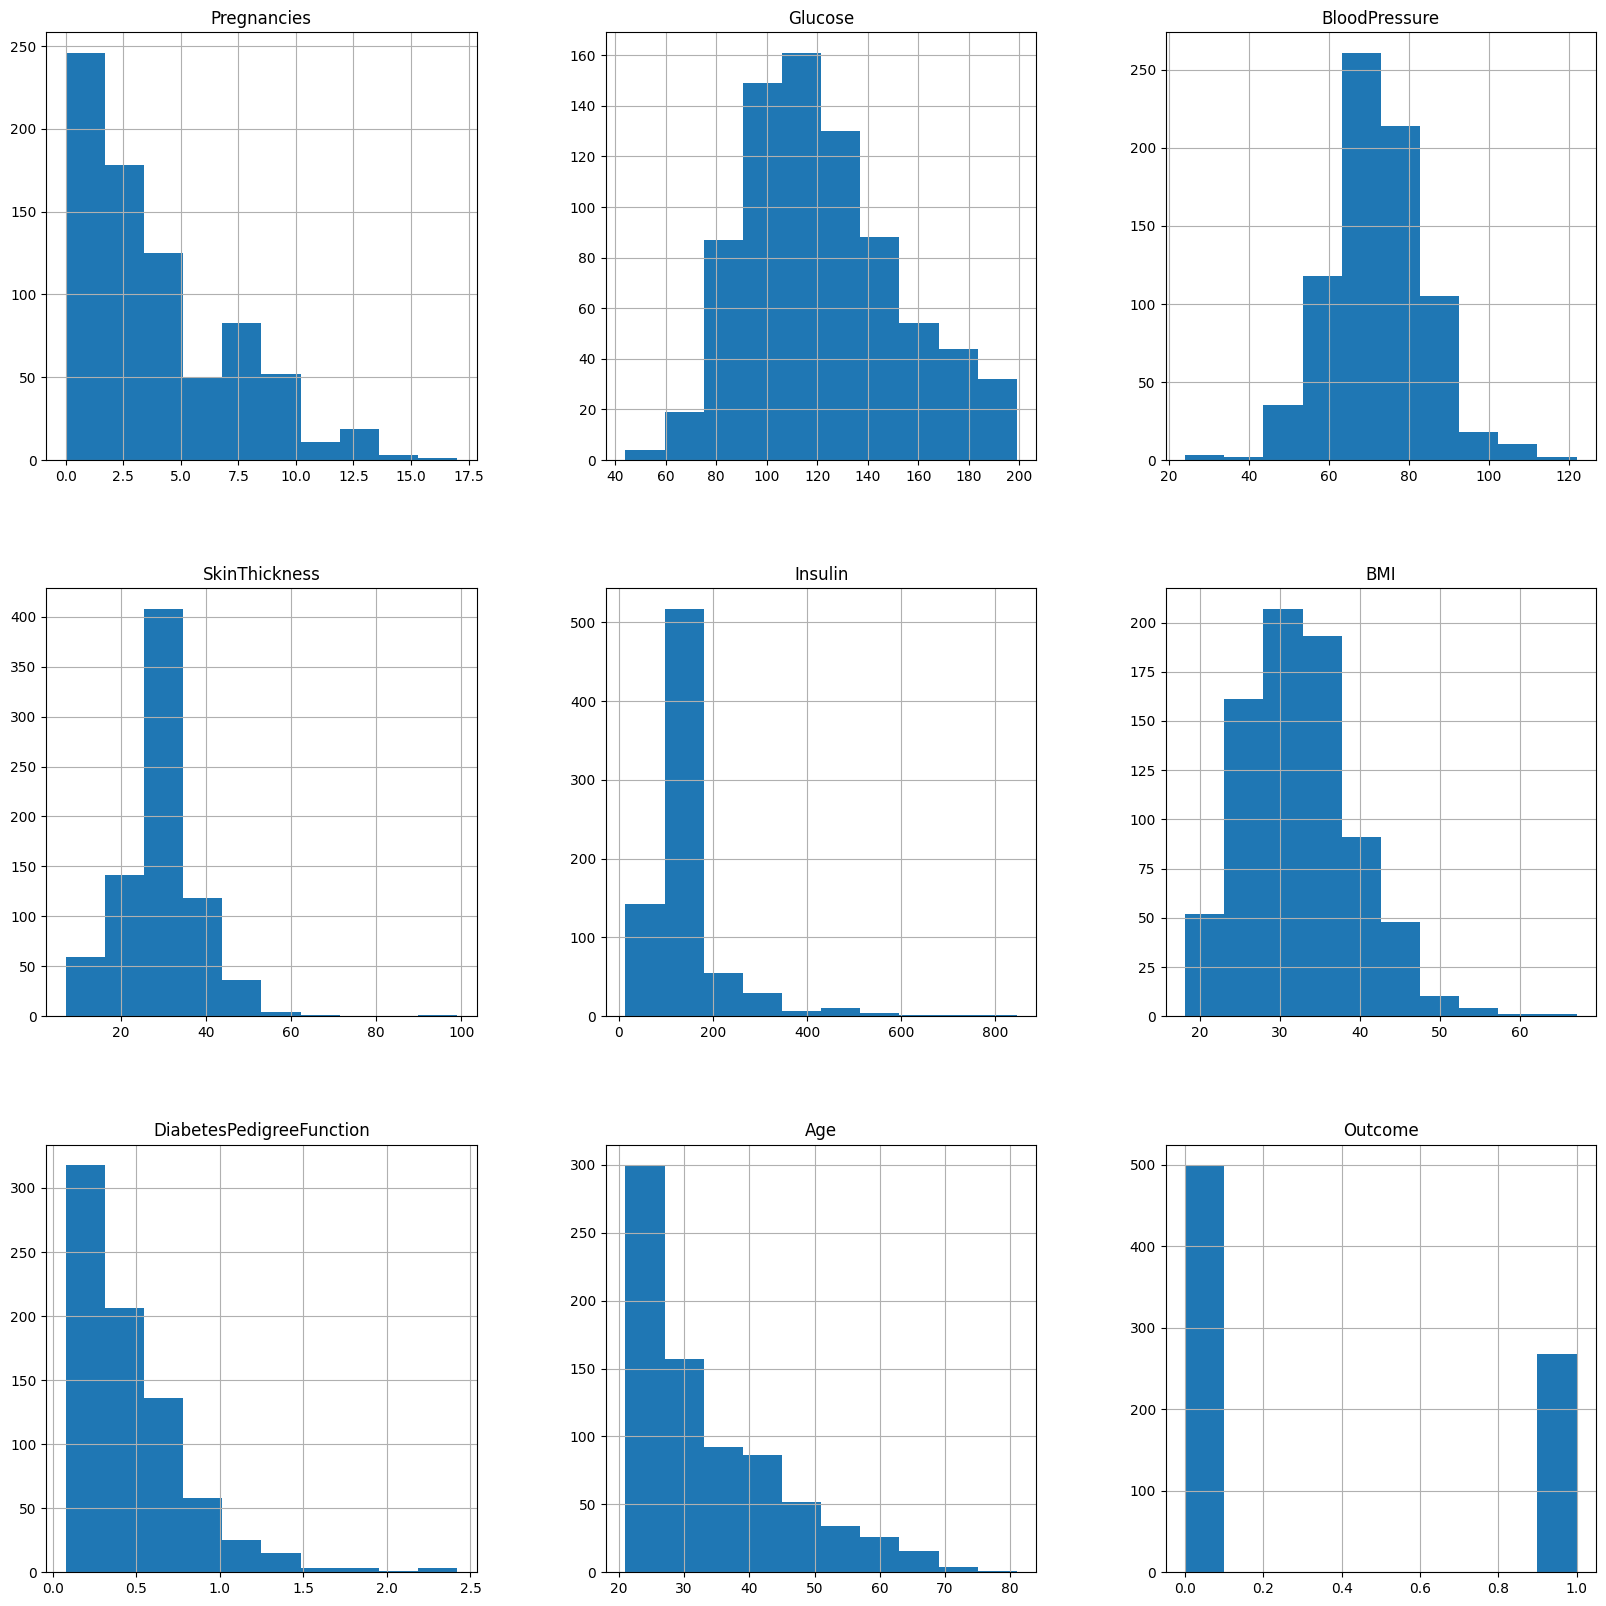

In [9]:
p = diabetes_data_copy.hist(figsize=(20, 20))
plt.show()

### Skewness Recap
Several columns (Insulin, DiabetesPedigreeFunction, Age) are **right-skewed**: a long tail stretching to the right, with the mean pulled above the median. This is the positive skew from class 1. Knowing the skew is exactly why we chose the median to impute those columns.

### Confirming No Missing Values (missingno)
The `missingno` library draws a quick visual of completeness. Full height bars mean no missing values, a good final check after imputation.

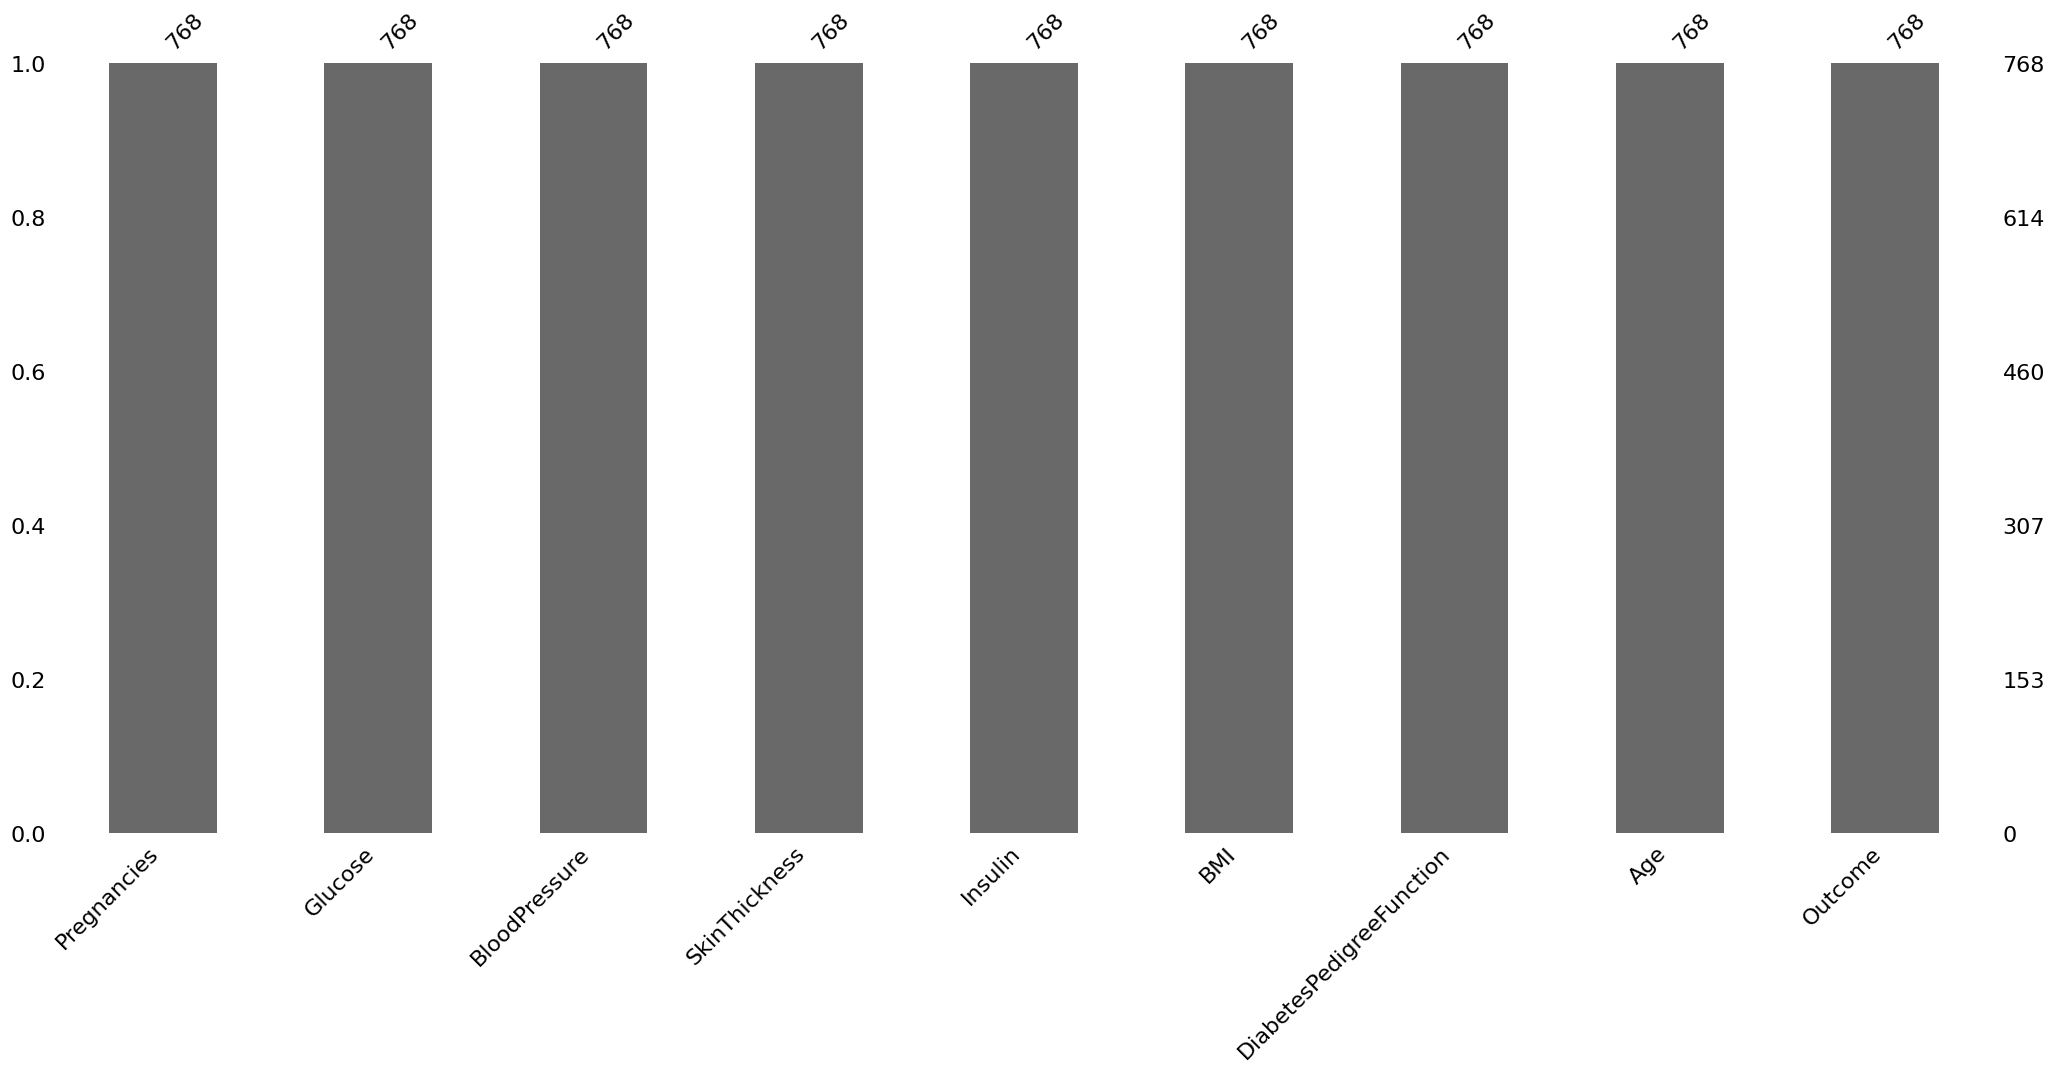

In [10]:
import missingno as msno
p = msno.bar(diabetes_data_copy)
plt.show()

### Class Balance
Before modeling, check how many of each Outcome we have. If one class dominates, the data is **imbalanced**, which matters for how we split and evaluate later.

Outcome
0    500
1    268
Name: count, dtype: int64


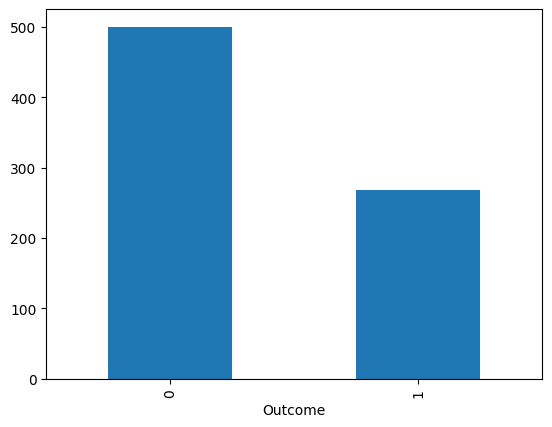

In [11]:
# value_counts - how many 0s and 1s in the target
print(diabetes_data_copy.Outcome.value_counts())
p = diabetes_data_copy.Outcome.value_counts().plot(kind='bar')
plt.show()
# 0 (no diabetes) is about twice 1 (diabetes): the data is imbalanced toward 0

### Scatter Matrix
A scatter matrix plots every feature against every other, with histograms on the diagonal. It is a fast way to scan all pairwise relationships and each feature's distribution in one grid.

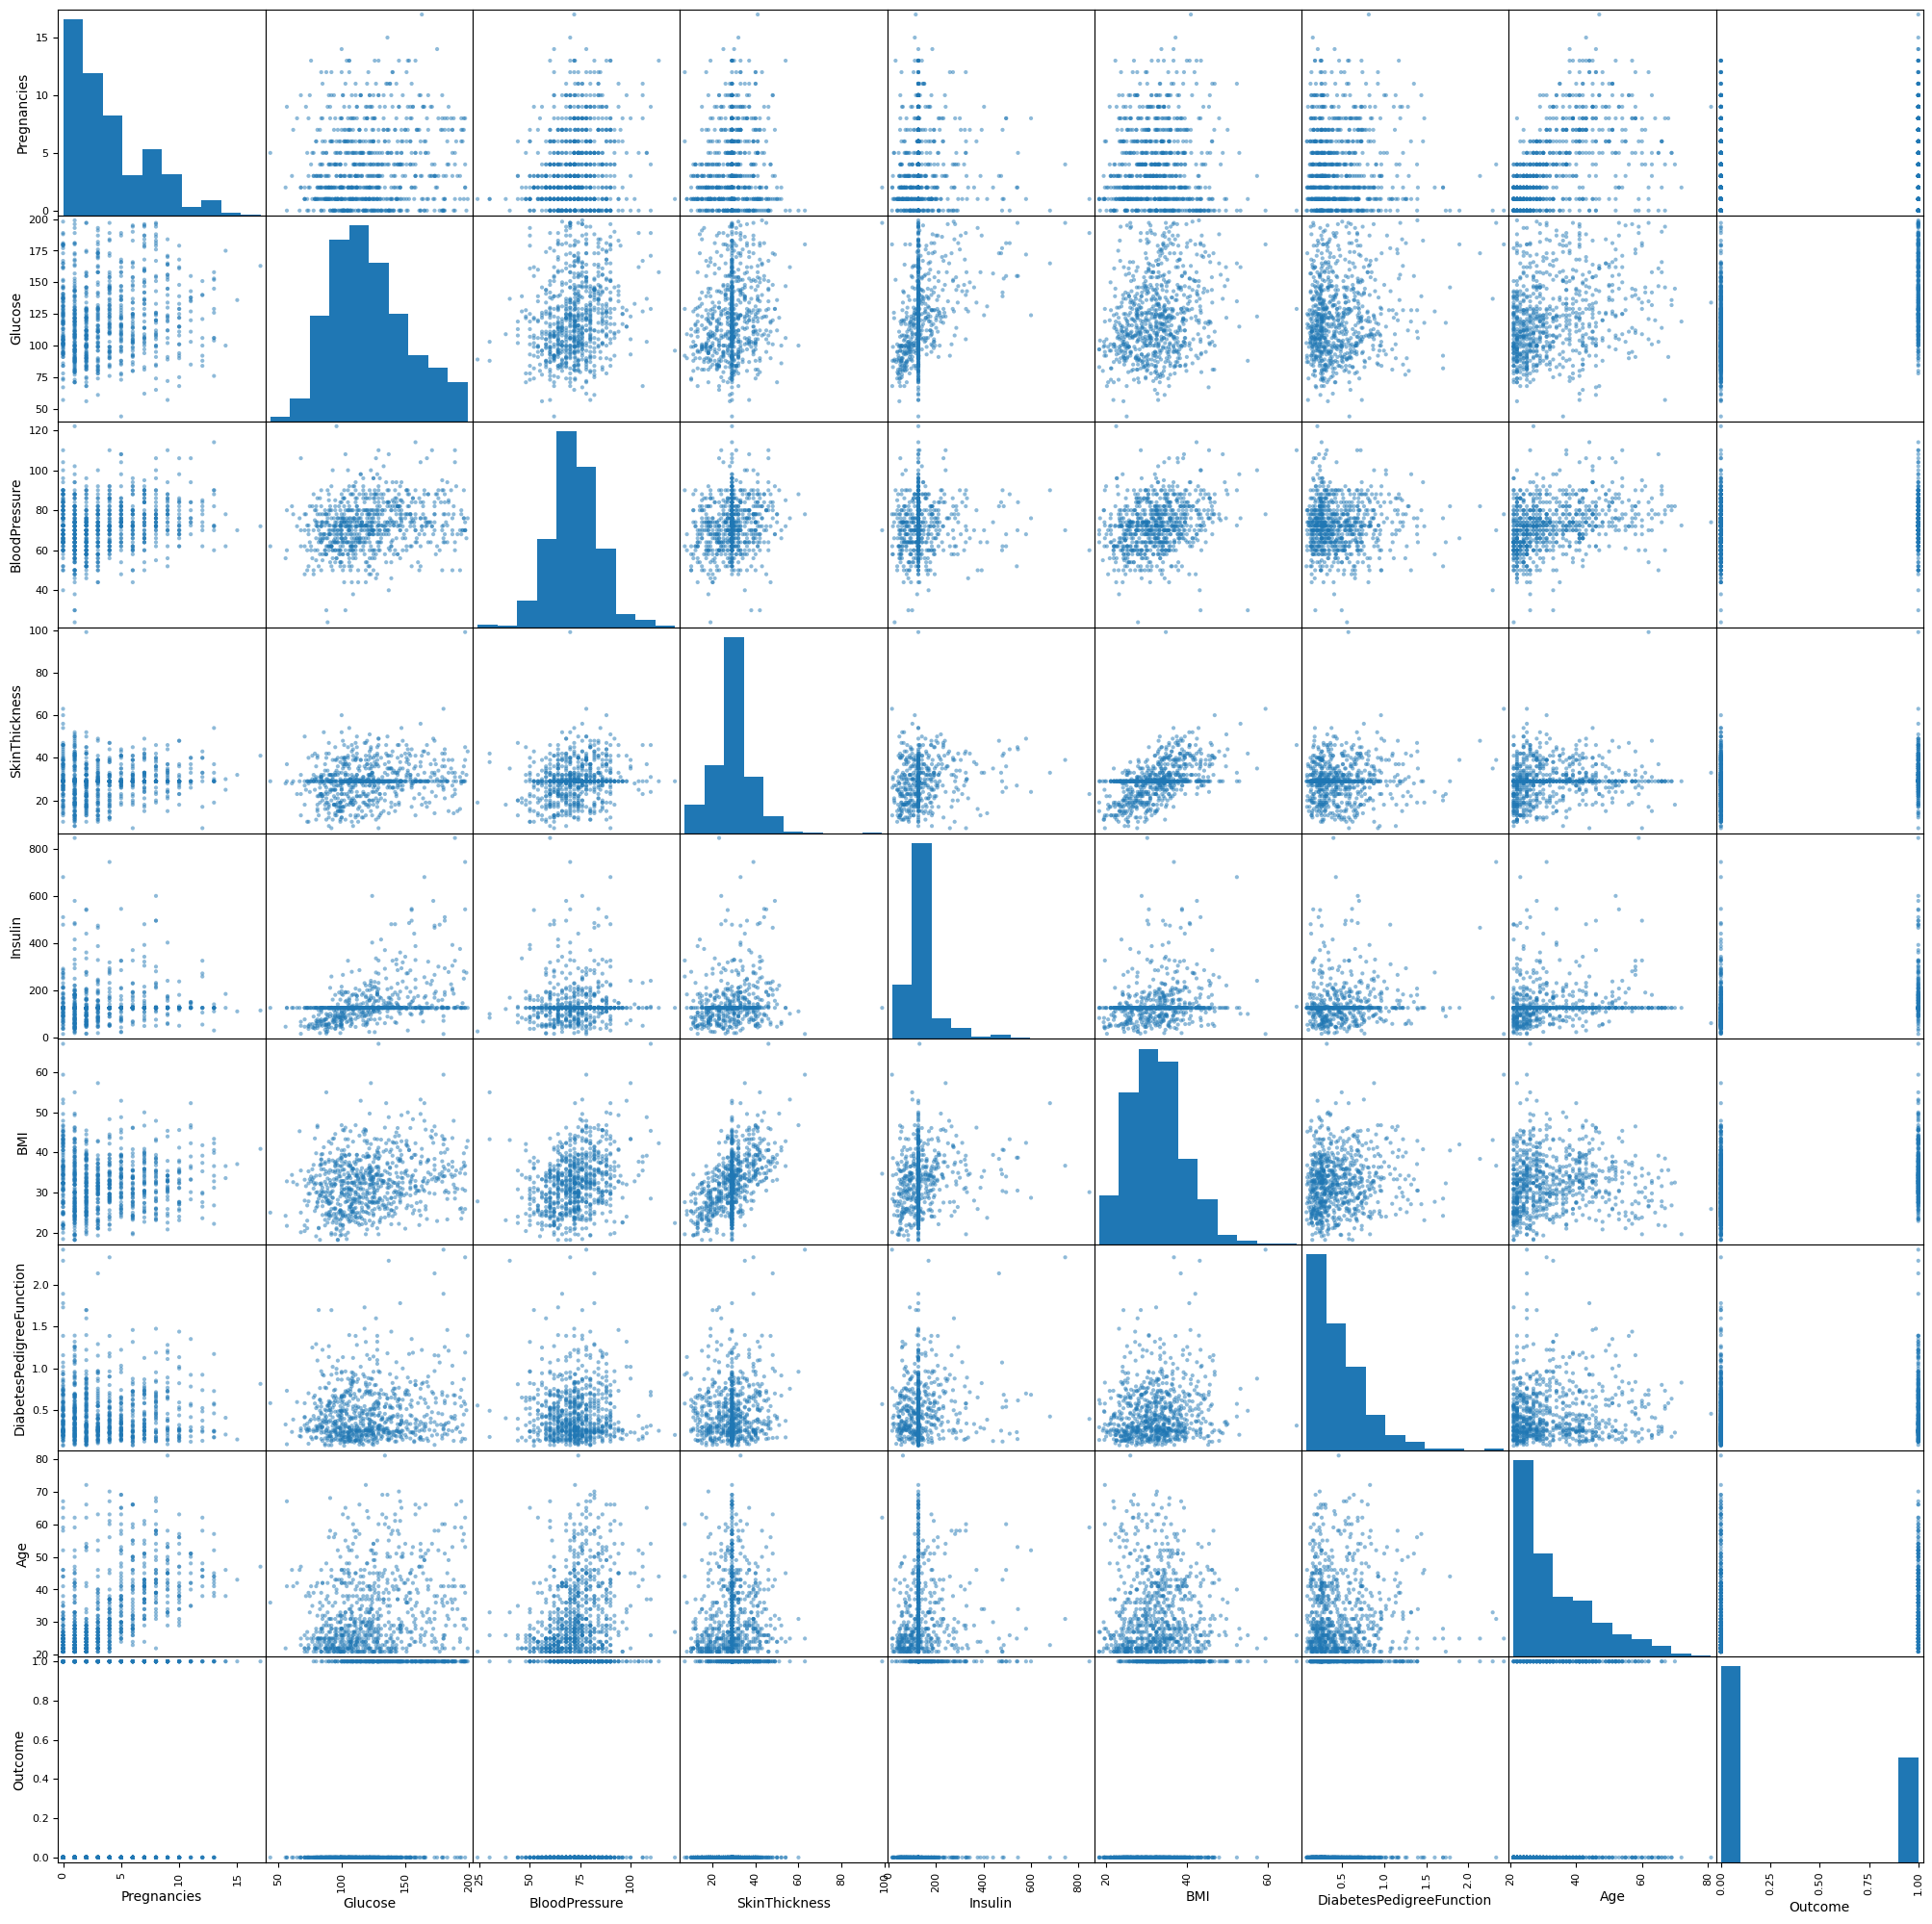

In [12]:
from pandas.plotting import scatter_matrix
p = scatter_matrix(diabetes_data_copy, figsize=(25, 25))
plt.show()

### Pair Plot (colored by Outcome)
seaborn's pairplot is the prettier version, and `hue='Outcome'` colors the points by class. Where the two colors separate, that feature helps distinguish diabetic from non-diabetic patients.

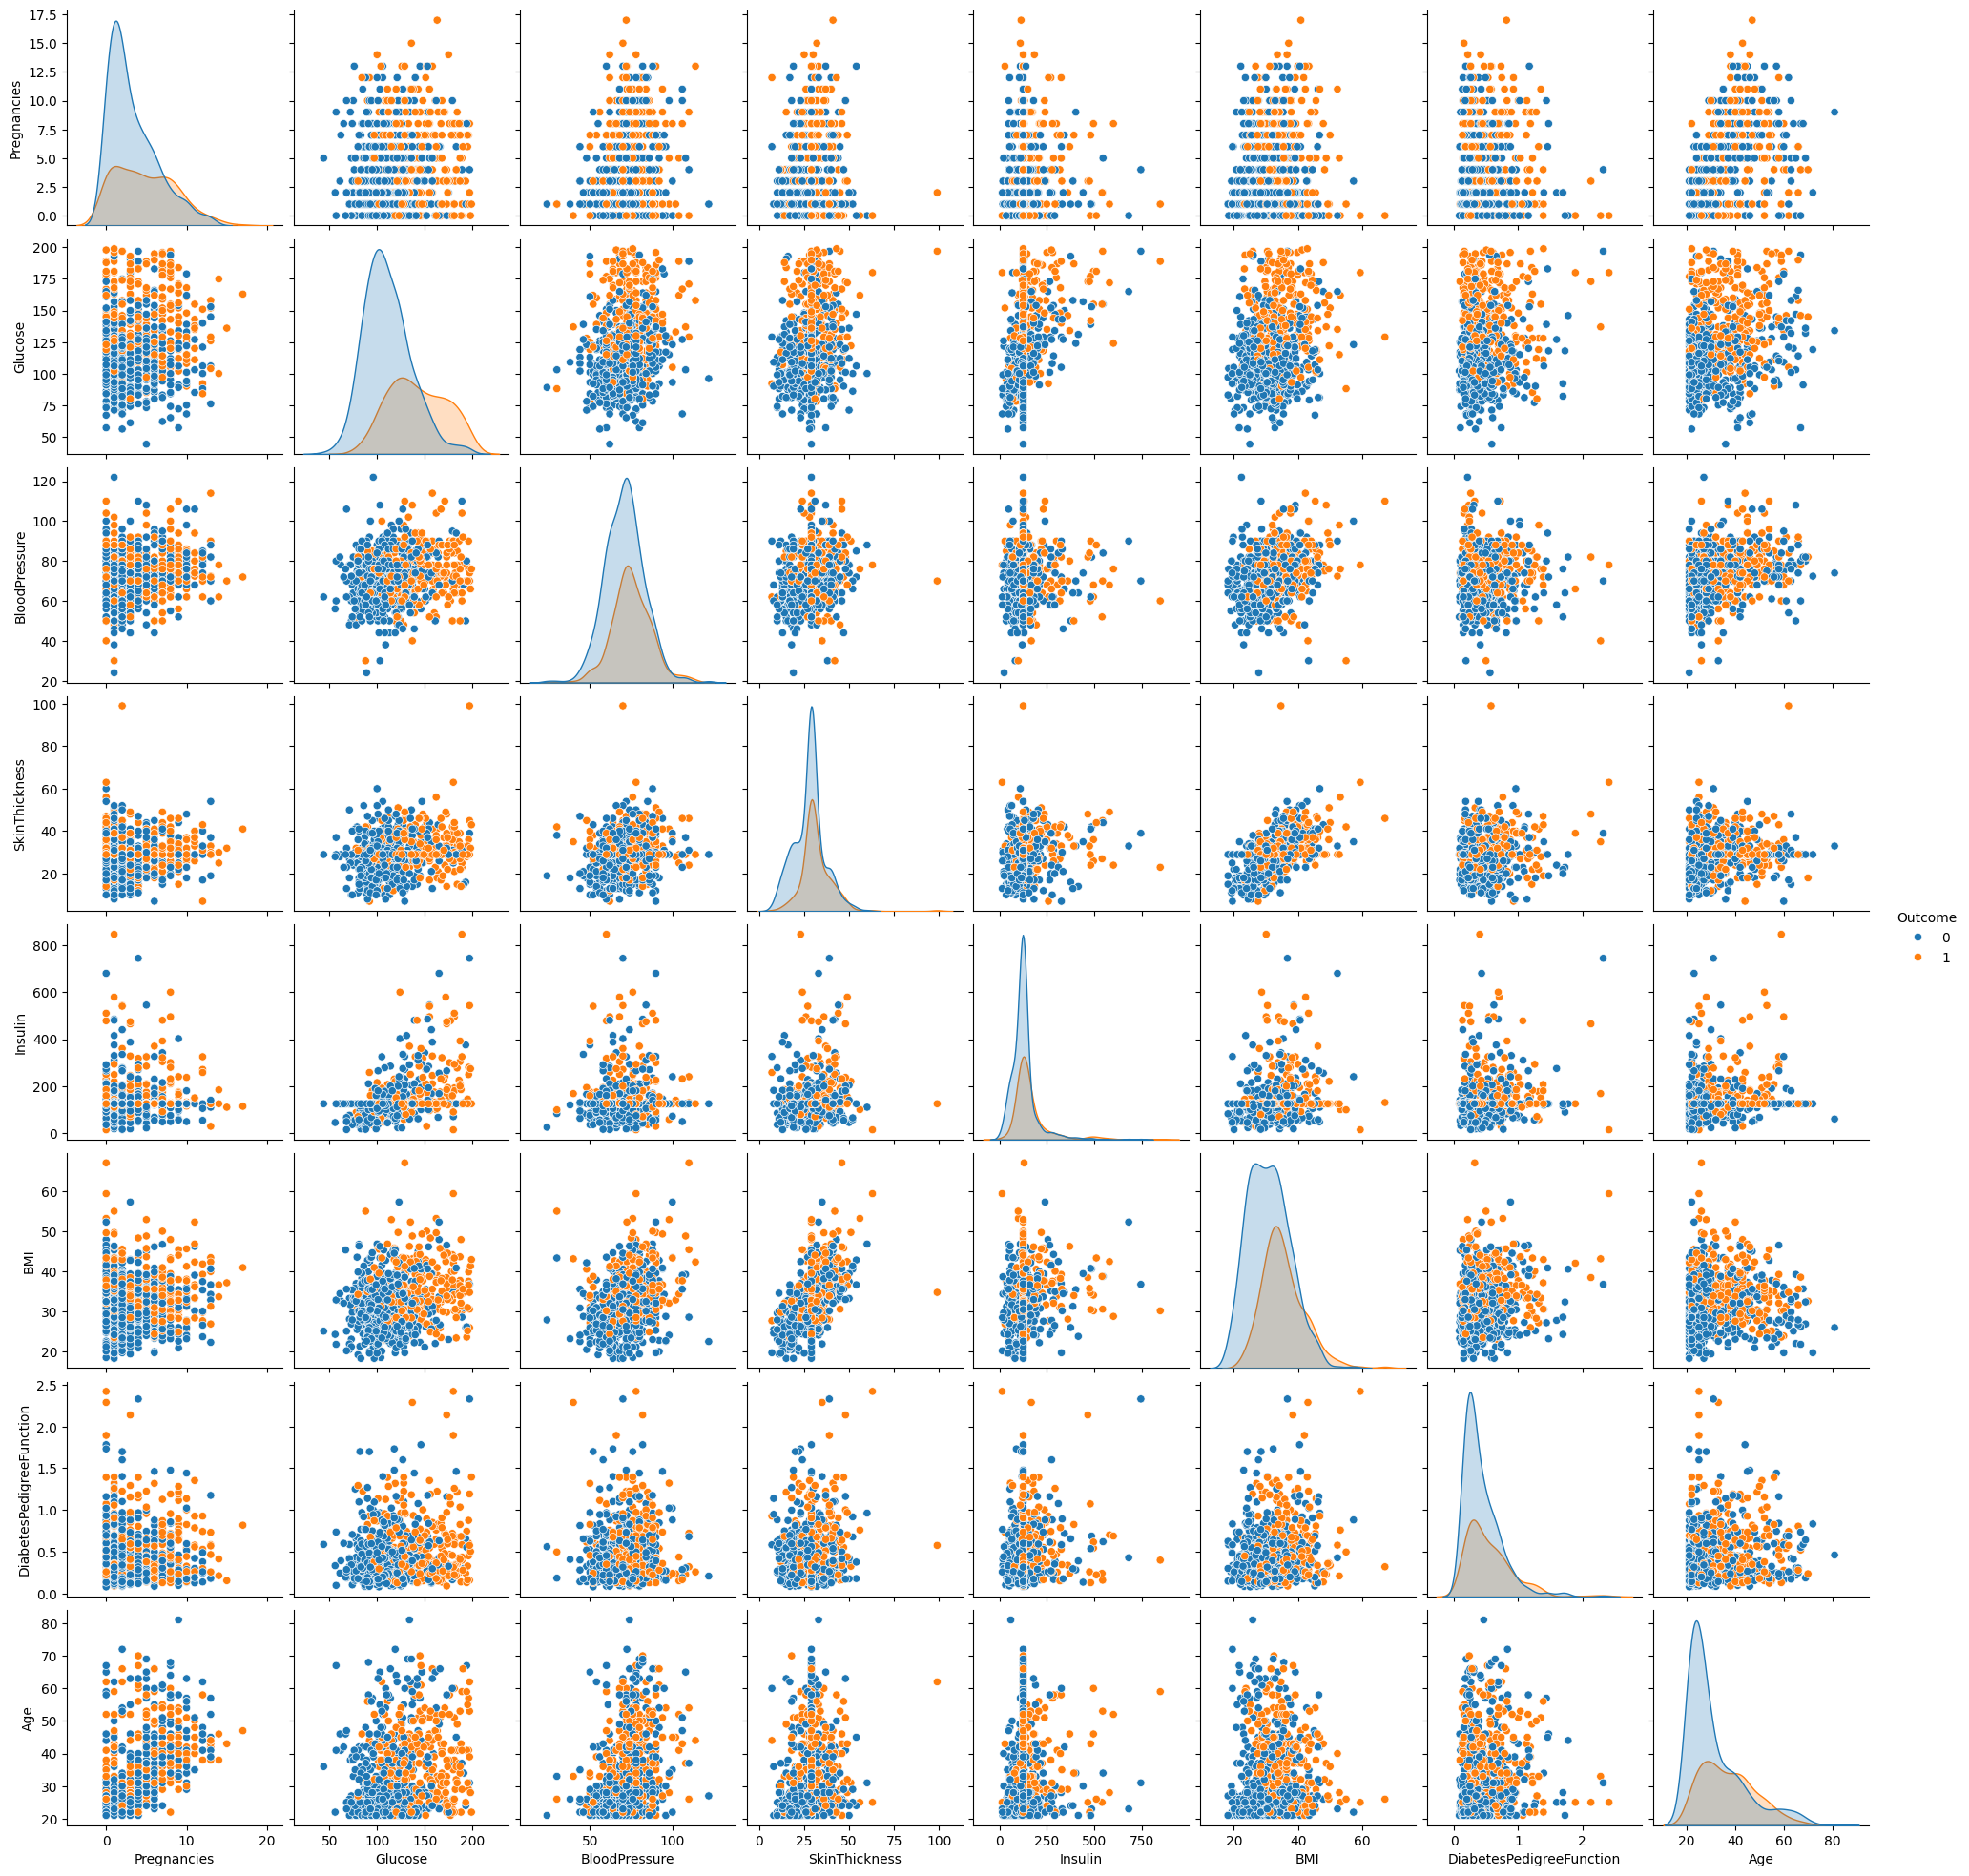

In [13]:
p = sns.pairplot(diabetes_data_copy, hue='Outcome')
plt.show()

### Correlation Heatmap
`corr()` computes the Pearson correlation between every pair of columns, and a heatmap colors it. Look down the Outcome row to see which features relate most to diabetes. Glucose has the strongest correlation with Outcome, which makes medical sense.

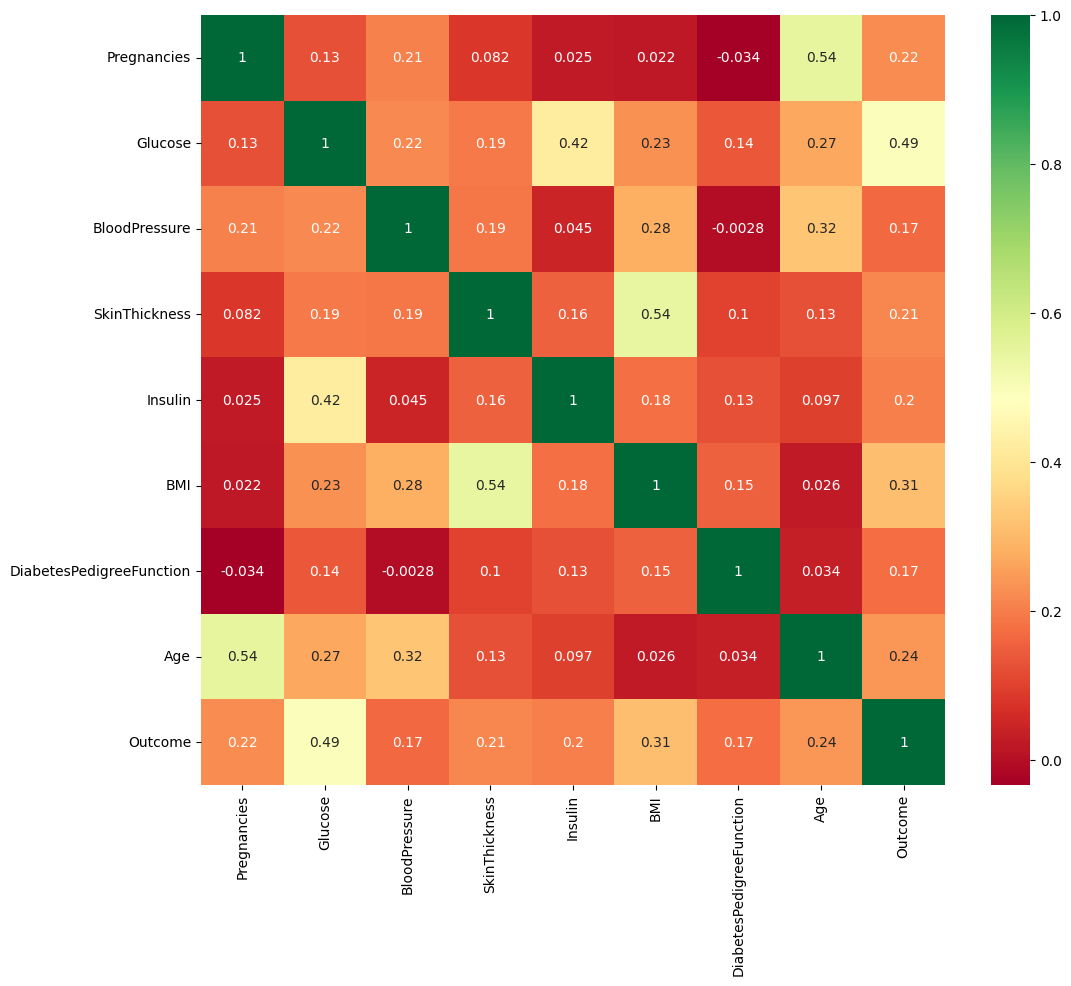

In [14]:
plt.figure(figsize=(12, 10))
p = sns.heatmap(diabetes_data_copy.corr(), annot=True, cmap='RdYlGn')
plt.show()

### Feature Scaling (Standardization)
The features are on very different scales (Insulin in the hundreds, DiabetesPedigreeFunction below 1). Many models work better when features are on the same scale. **Standardization** rescales each column to mean 0 and standard deviation 1 using the z-score from class 1:

z = (x - mean) / standard deviation

`StandardScaler` does this for every column at once.

In [15]:
from sklearn.preprocessing import StandardScaler
sc_X = StandardScaler()
# scale all features except the target (Outcome)
X = pd.DataFrame(
    sc_X.fit_transform(diabetes_data_copy.drop(['Outcome'], axis=1)),
    columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
             'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'])
X.head()   # every column now has mean 0 and SD 1

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.639947,0.865108,-0.033518,0.670643,-0.181541,0.166619,0.468492,1.425995
1,-0.844885,-1.206162,-0.529859,-0.012301,-0.181541,-0.852200,-0.365061,-0.190672
2,1.233880,2.015813,-0.695306,-0.012301,-0.181541,-1.332500,0.604397,-0.105584
3,-0.844885,-1.074652,-0.529859,-0.695245,-0.540642,-0.633881,-0.920763,-1.041549
4,-1.141852,0.503458,-2.680669,0.670643,0.316566,1.549303,5.484909,-0.020496


In [16]:
# the target stays as is
y = diabetes_data_copy.Outcome
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

### Train/Test Split and Cross Validation
- **Train/test split:** train the model on one part of the data and test on a separate part it has never seen. Testing on unseen data gives an honest measure of performance.
- **Cross validation:** repeatedly split into folds and rotate which fold is held out, so the score does not depend on one lucky or unlucky split. It guards against overfitting and underfitting.
- **stratify:** keeps the same class proportion (here about 65 percent 0, 35 percent 1) in both the train and test sets, which matters because our data is imbalanced.

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1/3, random_state=42, stratify=y)
print('train size:', X_train.shape[0], ' test size:', X_test.shape[0])

train size: 512  test size: 256


### KNN Model and Choosing k
**K Nearest Neighbors** classifies a point by looking at its k closest neighbors and taking the majority vote. The key choice is **k**. We try k from 1 to 14, recording train and test accuracy for each, then pick the k with the best test accuracy.

Note the pattern: at k = 1 the train score is perfect (the model just memorizes), but the test score is lower. That gap is overfitting. The right k balances the two.

In [18]:
from sklearn.neighbors import KNeighborsClassifier

test_scores = []
train_scores = []
for i in range(1, 15):
    knn = KNeighborsClassifier(i)
    knn.fit(X_train, y_train)
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))

print('train scores:', [round(s, 3) for s in train_scores])
print('test scores :', [round(s, 3) for s in test_scores])

train scores: [1.0, 0.844, 0.867, 0.836, 0.828, 0.805, 0.814, 0.803, 0.799, 0.803, 0.799, 0.793, 0.795, 0.797]
test scores : [0.73, 0.73, 0.746, 0.742, 0.742, 0.723, 0.746, 0.746, 0.746, 0.73, 0.766, 0.734, 0.75, 0.734]


In [19]:
# the best k is the one with the highest test accuracy
best_k = int(np.argmax(test_scores)) + 1
print('best k =', best_k, ' test accuracy =', round(max(test_scores), 4))

best k = 11  test accuracy = 0.7656


### Visualizing the Scores
Plotting train and test accuracy against k makes the tradeoff visible: train accuracy falls as k grows (less memorizing), and test accuracy peaks at the best k.

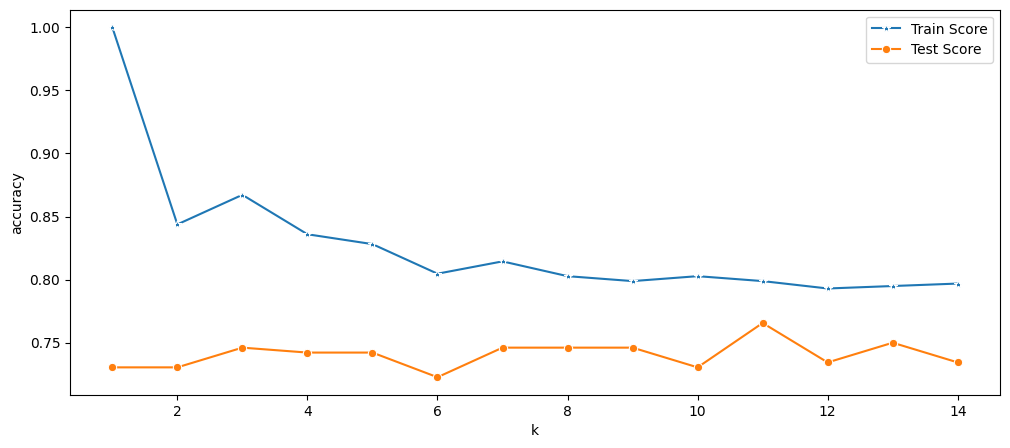

In [20]:
plt.figure(figsize=(12, 5))
sns.lineplot(x=range(1, 15), y=train_scores, marker='*', label='Train Score')
sns.lineplot(x=range(1, 15), y=test_scores, marker='o', label='Test Score')
plt.xlabel('k'); plt.ylabel('accuracy')
plt.show()

### Final KNN Model

In [21]:
# fit the final model using the best k found above
knn = KNeighborsClassifier(best_k)
knn.fit(X_train, y_train)
print('test accuracy:', round(knn.score(X_test, y_test), 4))

test accuracy: 0.7656


### Model Evaluation: Confusion Matrix
Accuracy alone hides what kind of mistakes the model makes. The **confusion matrix** breaks predictions into four boxes:

- **TP** (true positive): predicted diabetic, actually diabetic
- **TN** (true negative): predicted healthy, actually healthy
- **FP** (false positive): predicted diabetic, actually healthy (Type I error)
- **FN** (false negative): predicted healthy, actually diabetic (Type II error)

In a medical setting a false negative (missing a real case) is usually the most costly.

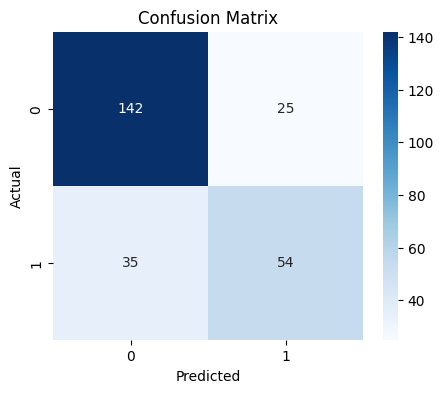

[[142  25]
 [ 35  54]]


In [22]:
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted'); plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
print(cm)

### Classification Report (Precision, Recall, F1)
Three metrics computed from the confusion matrix:

- **Precision = TP / (TP + FP):** of those predicted diabetic, how many really were. High precision means few false alarms.
- **Recall = TP / (TP + FN):** of those who are actually diabetic, how many we caught. High recall means few missed cases.
- **F1 = harmonic mean of precision and recall:** one balanced number, useful when classes are imbalanced (like here).

In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.85      0.83       167
           1       0.68      0.61      0.64        89

    accuracy                           0.77       256
   macro avg       0.74      0.73      0.73       256
weighted avg       0.76      0.77      0.76       256



### ROC and AUC
The **ROC curve** plots the true positive rate against the false positive rate as the decision threshold changes. **AUC** (area under the curve) summarizes it in one number: 0.5 is random guessing, 1.0 is perfect. A higher AUC means the model separates the two classes better.

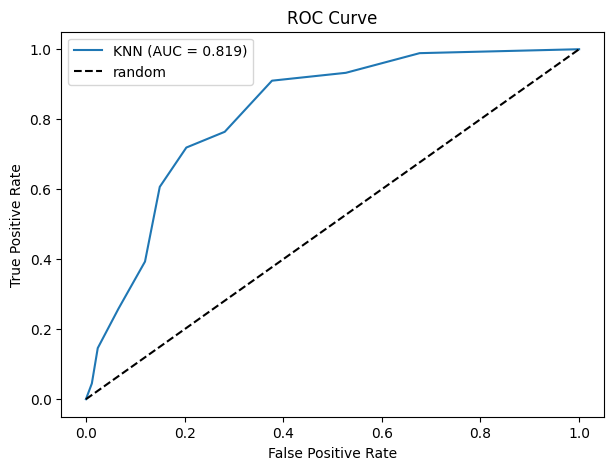

AUC: 0.8194


In [24]:
from sklearn.metrics import roc_curve, roc_auc_score
y_pred_proba = knn.predict_proba(X_test)[:, 1]   # probability of class 1
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'KNN (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend()
plt.show()
print('AUC:', round(auc, 4))

### Hyperparameter Tuning: GridSearchCV
The manual loop tested k on a single split. **Grid search** tries every value in a grid using cross validation (here 5 folds), so the chosen k is based on an averaged, more reliable score rather than one split. It is thorough but slower, since it fits a model for every combination.

In [25]:
from sklearn.model_selection import GridSearchCV
param_grid = {'n_neighbors': np.arange(1, 50)}
knn_cv = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)
knn_cv.fit(X, y)
print('Best Score:', round(knn_cv.best_score_, 4))
print('Best Parameters:', knn_cv.best_params_)

Best Score: 0.7722
Best Parameters: {'n_neighbors': np.int64(25)}


### Recap
The full EDA pipeline, start to finish:

1. **Load and inspect** with head, info, describe
2. **Data quality:** spot impossible zeros, mark them as missing
3. **Impute:** mean for symmetric columns, median for skewed ones
4. **Explore:** histograms, class balance, scatter matrix, pair plot, correlation heatmap
5. **Scale:** standardize features to mean 0, SD 1 (z-score)
6. **Split:** stratified train/test plus cross validation
7. **Model:** KNN, tune k by test accuracy and by grid search
8. **Evaluate:** confusion matrix, precision/recall/F1, ROC AUC

Notice how much of this is class 1 statistics in disguise: describe is descriptive stats, the median imputation uses skew, scaling is the z-score, and the correlation heatmap is correlation. EDA is where statistics meets real data.